/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet152_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet152_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


--2026-04-06 01:58:11--  https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10472 (10K) [text/plain]
Saving to: ‘imagenet_classes.txt’

imagenet_classes.tx 100%[===================>]  10.23K  --.-KB/s    in 0s      

2026-04-06 01:58:11 (21.1 MB/s) - ‘imagenet_classes.txt’ saved [10472/10472]



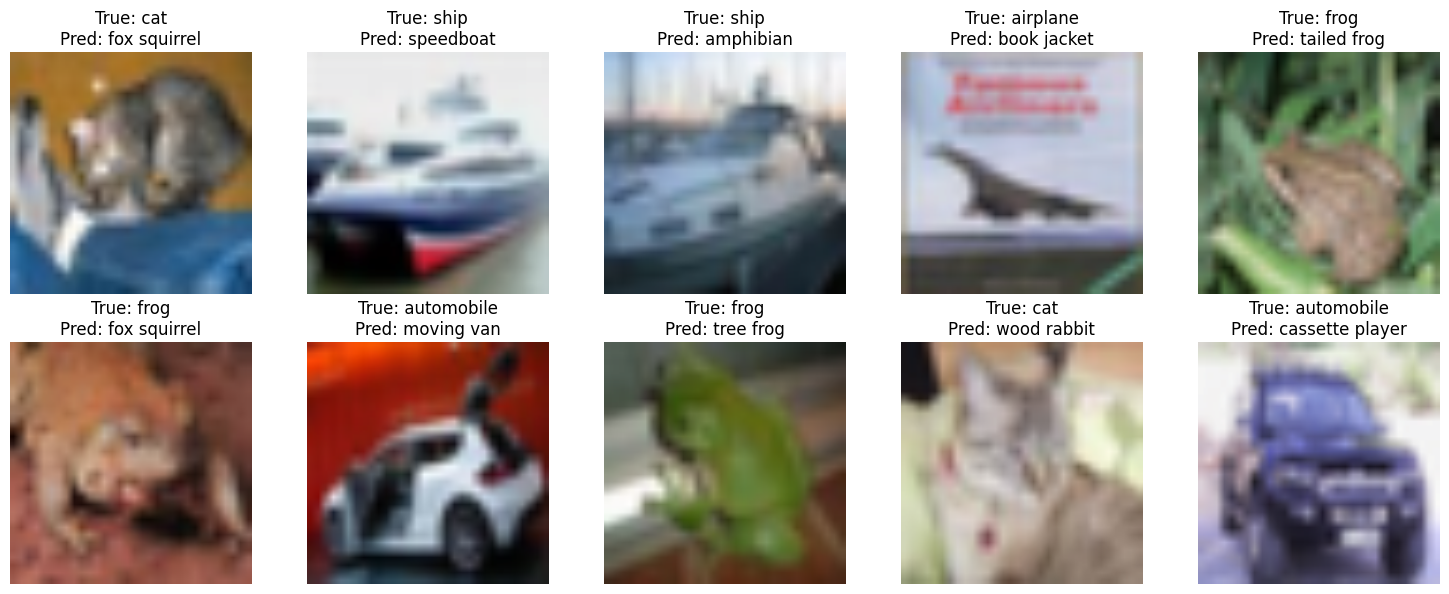

Image 1: True Label = cat, Predicted Label = fox squirrel
Image 2: True Label = ship, Predicted Label = speedboat
Image 3: True Label = ship, Predicted Label = amphibian
Image 4: True Label = airplane, Predicted Label = book jacket
Image 5: True Label = frog, Predicted Label = tailed frog
Image 6: True Label = frog, Predicted Label = fox squirrel
Image 7: True Label = automobile, Predicted Label = moving van
Image 8: True Label = frog, Predicted Label = tree frog
Image 9: True Label = cat, Predicted Label = wood rabbit
Image 10: True Label = automobile, Predicted Label = cassette player


In [6]:
import torch
import torchvision.transforms as transforms
import torchvision.models as models
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, Subset
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pretrained ResNet-152
model = models.resnet152(pretrained=True)
model = model.to(device)
model.eval()

# ImageNet normalization
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Example dataset: CIFAR-10
dataset = datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

# Take first 10 images
subset = Subset(dataset, range(10))
loader = DataLoader(subset, batch_size=1, shuffle=False)

# CIFAR-10 class names
cifar10_classes = dataset.classes

# Download ImageNet class labels if not already present
import os
if not os.path.exists("imagenet_classes.txt"):
    !wget -nc https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt

# Load ImageNet class labels
with open("imagenet_classes.txt", "r") as f:
    imagenet_classes = [line.strip() for line in f.readlines()]

# Optional: ImageNet labels
predictions = []

# Helper transform for showing original image
display_transform = transforms.Compose([
    transforms.Resize((224, 224))
])

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

with torch.no_grad():
    for i, (image, true_label) in enumerate(loader):
        image = image.to(device)
        output = model(image)
        _, predicted = torch.max(output, 1)

        predictions.append((i, true_label.item(), predicted.item()))

        # Convert image for display
        img_np = image[0].cpu().numpy().transpose(1, 2, 0)
        img_np = np.array([0.229, 0.224, 0.225]) * img_np + np.array([0.485, 0.456, 0.406])
        img_np = np.clip(img_np, 0, 1)

        ax = axes[i // 5, i % 5]
        ax.imshow(img_np)
        ax.set_title(f"True: {cifar10_classes[true_label.item()]}\nPred: {imagenet_classes[predicted.item()]}")
        ax.axis("off")

plt.tight_layout()
plt.show()

# Print predictions
for idx, true_lbl, pred_lbl in predictions:
    print(f"Image {idx+1}: True Label = {cifar10_classes[true_lbl]}, Predicted Label = {imagenet_classes[pred_lbl]}")

In [ ]:
import os

image_folder = "test_images"

# Create the directory if it doesn't exist
if not os.path.exists(image_folder):
    os.makedirs(image_folder)
    print(f"Created directory: {image_folder}")
else:
    print(f"Directory already exists: {image_folder}")

Created directory: test_images


In [ ]:
import os
from PIL import Image
import torch
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet152(pretrained=True)
model = model.to(device)
model.eval()

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

image_folder = "test_images"
image_files = os.listdir(image_folder)[:10]

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

with torch.no_grad():
    for i, file_name in enumerate(image_files):
        img_path = os.path.join(image_folder, file_name)
        image = Image.open(img_path).convert("RGB")
        input_tensor = transform(image).unsqueeze(0).to(device)

        output = model(input_tensor)
        _, predicted = torch.max(output, 1)

        ax = axes[i // 5, i % 5]
        ax.imshow(image)
        ax.set_title(f"Pred ID: {predicted.item()}")
        ax.axis("off")

plt.tight_layout()
plt.show()

No image files found in 'test_images'. Please upload images to this directory.


In [ ]:
# Download ImageNet class labels
!wget -nc https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt

--2026-04-05 18:15:06--  https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10472 (10K) [text/plain]
Saving to: ‘imagenet_classes.txt’

imagenet_classes.tx 100%[===================>]  10.23K  --.-KB/s    in 0.001s  

2026-04-05 18:15:06 (18.3 MB/s) - ‘imagenet_classes.txt’ saved [10472/10472]



In [ ]:
# Load ImageNet class labels
with open("imagenet_classes.txt", "r") as f:
    imagenet_classes = [line.strip() for line in f.readlines()]